<a href="https://colab.research.google.com/github/Genius-boop/controler/blob/main/GUIDE%20prediction%20de%20la%20duree%20de%20trajet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# chargement des données
dv = pd.read_excel('duree de trajet.xlsx')

In [4]:
print(dv.head())

   distance_km    road_type  vehicle  duration_min
0           15      bitumée     moto          15.2
1           42      bitumée  voiture          50.8
2            8  non_bitumée     moto          14.1
3           23  non_bitumée  voiture          46.5
4           67      bitumée     moto          67.3


In [6]:
print(dv.shape)
print(dv.info())
print(dv.describe())

(346, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   distance_km   346 non-null    int64  
 1   road_type     346 non-null    object 
 2   vehicle       346 non-null    object 
 3   duration_min  346 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 10.9+ KB
None
       distance_km  duration_min
count   346.000000    346.000000
mean     45.965318     65.082659
std      28.645134     40.249807
min       1.000000      2.100000
25%      23.000000     31.825000
50%      41.500000     49.800000
75%      66.750000     98.400000
max     119.000000    162.700000


In [15]:
dv.isnull().sum()

,0
distance_km,0
road_type,0
vehicle,0
duration_min,0


<Axes: >

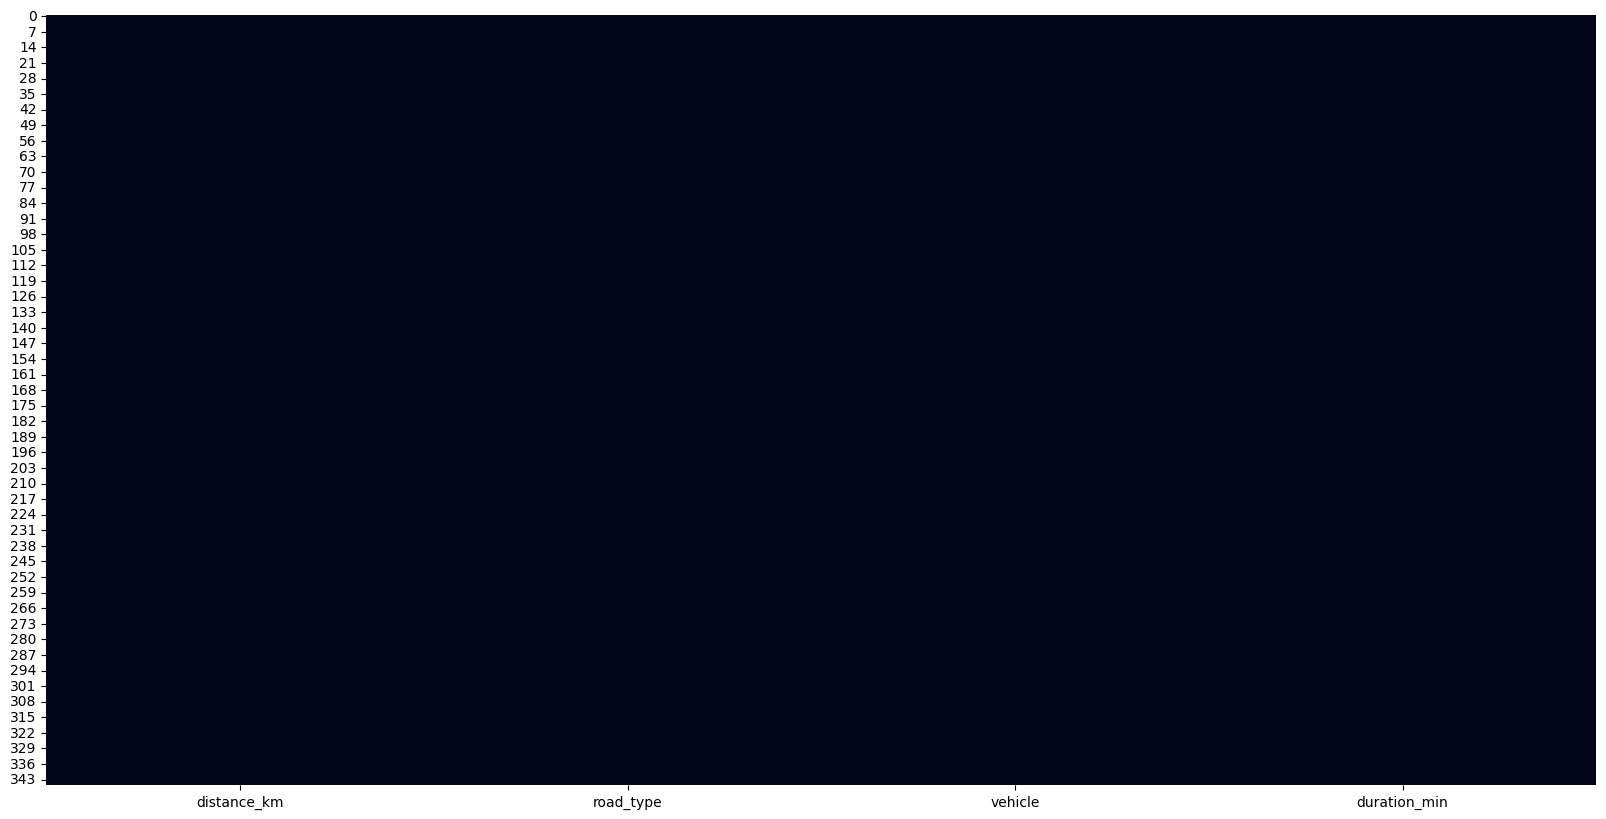

In [18]:
#visualiser l'histogramme des valeurs manquantes
plt.figure(figsize=(20,10))
sns.heatmap(dv.isnull(),cbar=False)

In [22]:
dv.sample(5)

,distance_km,road_type,vehicle,duration_min
243,77,non_bitumée,voiture,154.8
123,72,non_bitumée,voiture,144.8
261,33,bitumée,voiture,40.1
284,106,bitumée,moto,106.2
111,37,non_bitumée,voiture,74.6


In [26]:
dv = dv[['distance_km','road_type','vehicle','duration_min']]
dv.dropna(axis=0, inplace=True)
dv['road_type'] = dv['road_type'].replace(['bitumée','non_bitumée'],[1,0])
dv['vehicle'] = dv['vehicle'].replace(['moto','voiture'],[0,1])

In [27]:
# Définition des features (x) et de la cible (y)
Y = dv['duration_min']
X = dv.drop('duration_min', axis=1)

In [28]:
Y

,duration_min
0,15.2
1,50.8
2,14.1
3,46.5
4,67.3
...,...
341,41.6
342,50.6
343,134.9
344,50.9


In [29]:
X

,distance_km,road_type,vehicle
0,15,1,0
1,42,1,1
2,8,0,0
3,23,0,1
4,67,1,0
...,...,...,...
341,34,1,1
342,29,0,0
343,67,0,1
344,50,1,0


In [32]:
# Découpage 80% train set et 20% test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [34]:
# Entrainement et Evaluation du modèle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Entainement du modèle
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [35]:
# Prédiction sur le jeu de test
Y_pred = model.predict(X_test)

In [37]:
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))
r2 = r2_score(Y_test,Y_pred)
print(f"RMSE:{rmse:.4f}")
print(f"R2:{r2:.4f}")

RMSE:8.7662
R2:0.9597


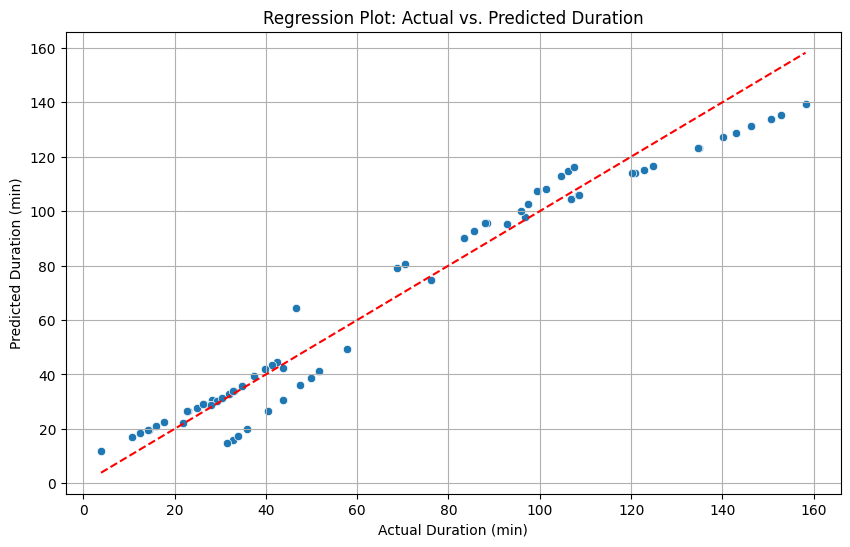

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Duration (min)')
plt.ylabel('Predicted Duration (min)')
plt.title('Regression Plot: Actual vs. Predicted Duration')
plt.grid(True)
plt.show()

In [43]:
# Définition de la fonction de prédiction
def predict_duration(model, distance_km, road_type, vehicle):
    input_data = pd.DataFrame([[distance_km, road_type, vehicle]],
                             columns=['distance_km', 'road_type', 'vehicle'])
    prediction = model.predict(input_data)[0]
    return prediction

In [44]:
# Prédiction
resultat = predict_duration(model, distance_km=60, road_type=0, vehicle=1)
print(f"Durée prévue de trajet: {resultat:.2f} minutes")

Durée prévue de trajet: 113.94 minutes
